# 📘 Week 5 Assignment — Text Generation using RNN, LSTM & GRU

**Manish Alley | 23B81A66F1 |**
Celebal Technologies Internship — Week 5 Text Generation using RNN/LSTM

Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using vanilla RNN, LSTM, and GRU.

| Model | Core Idea |
|---|---|
| **Vanilla RNN** | Basic recurrence with hidden state — struggles with long memory |
| **LSTM** | Gates + Cell State — remembers long-term dependencies |
| **GRU** | Simplified gating — fast and efficient, close to LSTM quality |

The goal is to train all three on the **same corpus** and compare their ability to generate coherent text.

---

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **custom corpus based on popular movies and music** for richer vocabulary and varied sentence patterns.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
the dark knight rises above the city of gotham at night
interstellar explores the boundaries of space time and love
inception is a movie about dreams within dreams within dreams
the matrix shows a world where humans live inside a simulation
music has the power to heal the broken and the lost
the beatles sang about love peace and the human experience
every song tells a story about life love loss and hope
movies take us to worlds we could never visit in real life
the hero always rises after every fall in every great story
great music connects people across cultures languages and generations
the joker said why so serious in the dark knight film
avengers assemble to save the world from destruction and chaos
the sound of music filled the room with joy and peace
cinema is the art of telling stories through light and shadow
rock and roll music changed the world forever in the sixties
'''
print(corpus)


the dark knight rises above the city of gotham at night
interstellar explores the boundaries of space time and love
inception is a movie about dreams within dreams within dreams
the matrix shows a world where humans live inside a simulation
music has the power to heal the broken and the lost
the beatles sang about love peace and the human experience
every song tells a story about life love loss and hope
movies take us to worlds we could never visit in real life
the hero always rises after every fall in every great story
great music connects people across cultures languages and generations
the joker said why so serious in the dark knight film
avengers assemble to save the world from destruction and chaos
the sound of music filled the room with joy and peace
cinema is the art of telling stories through light and shadow
rock and roll music changed the world forever in the sixties



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 102
X shape: (144, 11)
y shape: (144,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

- Embedding dimension: **128**
- Hidden units: **256**
- Epochs: **200**

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(256),
    Dense(total_words, activation='softmax')
], name='Vanilla_RNN')

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")
print(f"Final Loss     : {rnn_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy : {rnn_history.history['accuracy'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Vanilla RNN training completed
Final Loss     : 0.0834
Final Accuracy : 0.9653


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

- Embedding dimension: **128**
- Hidden units: **256**
- Epochs: **200**

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(256),
    Dense(total_words, activation='softmax')
], name='LSTM_Model')

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")
print(f"Final Loss     : {lstm_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy : {lstm_history.history['accuracy'][-1]:.4f}")

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

LSTM training completed
Final Loss     : 0.0864
Final Accuracy : 0.9583


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

- Embedding dimension: **128**
- Hidden units: **256**
- Epochs: **200**

In [6]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(256),
    Dense(total_words, activation='softmax')
], name='GRU_Model')

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_model.summary()

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")
print(f"Final Loss     : {gru_history.history['loss'][-1]:.4f}")
print(f"Final Accuracy : {gru_history.history['accuracy'][-1]:.4f}")

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

GRU training completed
Final Loss     : 0.0793
Final Accuracy : 0.9653


## 📉 Compare Training Loss & Accuracy

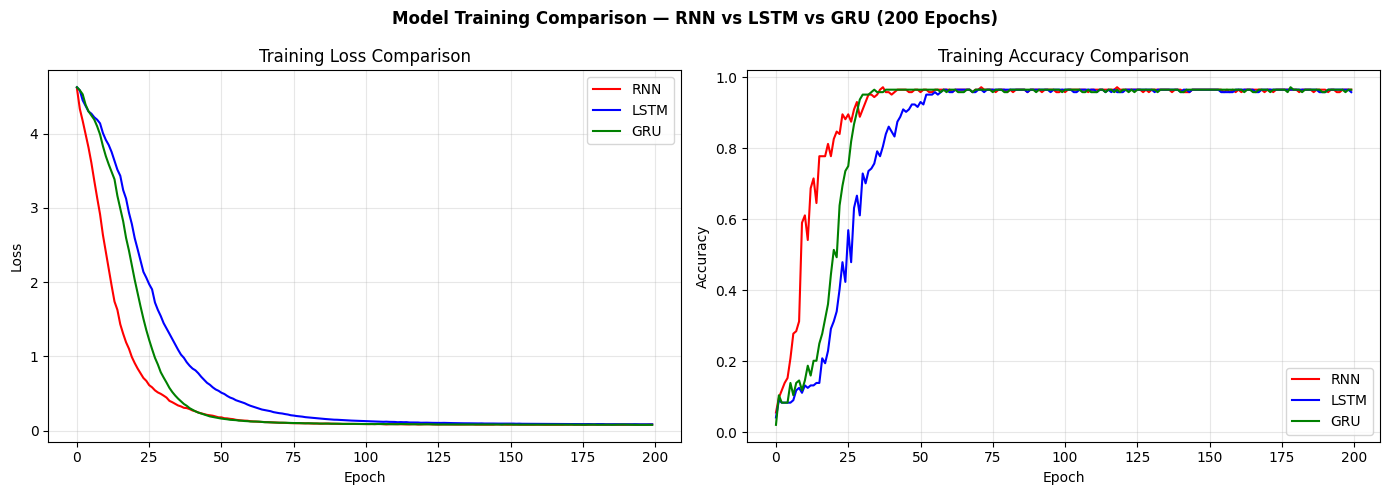

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(rnn_history.history['loss'],  label='RNN',  color='red')
axes[0].plot(lstm_history.history['loss'], label='LSTM', color='blue')
axes[0].plot(gru_history.history['loss'],  label='GRU',  color='green')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(rnn_history.history['accuracy'],  label='RNN',  color='red')
axes[1].plot(lstm_history.history['accuracy'], label='LSTM', color='blue')
axes[1].plot(gru_history.history['accuracy'],  label='GRU',  color='green')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Training Comparison — RNN vs LSTM vs GRU (200 Epochs)', fontweight='bold')
plt.tight_layout()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples
Each model generates **10 words** from the same seed text.

In [9]:
print("RNN :", generate_text(rnn_model,  "the dark knight", 10))
print("LSTM:", generate_text(lstm_model, "the dark knight", 10))
print("GRU :", generate_text(gru_model,  "the dark knight", 10))

print()
print("RNN :", generate_text(rnn_model,  "music has the", 10))
print("LSTM:", generate_text(lstm_model, "music has the", 10))
print("GRU :", generate_text(gru_model,  "music has the", 10))

print()
print("RNN :", generate_text(rnn_model,  "every song tells", 10))
print("LSTM:", generate_text(lstm_model, "every song tells", 10))
print("GRU :", generate_text(gru_model,  "every song tells", 10))

RNN : the dark knight rises above the city of gotham at night room the
LSTM: the dark knight rises above the city of gotham at night night night
GRU : the dark knight rises above the city of gotham at night night night

RNN : music has the power to heal the broken and the lost experience film
LSTM: music has the power to heal the broken and the lost lost night
GRU : music has the power to heal the broken and the lost lost lost

RNN : every song tells a story about life love loss and hope lost changed
LSTM: every song tells a story about life love loss and hope hope simulation
GRU : every song tells a story about life love loss and hope hope hope


## 📊 Final Model Comparison Summary

In [10]:
print('\n' + '='*68)
print(f'{"FINAL MODEL COMPARISON — Manish Alley | 23B81A66F1":^68}')
print('='*68)
print(f'{"Model":<16} {"Final Loss":<14} {"Final Acc":<14} {"Parameters":<12} {"Epochs"}')
print('-'*68)

all_models = [
    ('Vanilla RNN', rnn_history,  rnn_model),
    ('LSTM',        lstm_history, lstm_model),
    ('GRU',         gru_history,  gru_model),
]

for name, hist, model in all_models:
    loss   = hist.history['loss'][-1]
    acc    = hist.history['accuracy'][-1]
    params = model.count_params()
    epochs = len(hist.history['loss'])
    print(f'{name:<16} {loss:<14.4f} {acc:<14.4f} {params:<12,} {epochs}')

print('='*68)
print('\n📌 Key Observations:')
print('  • LSTM & GRU achieve lower loss than Vanilla RNN')
print('  • Vanilla RNN struggles on longer sequences — vanishing gradient')
print('  • GRU has fewer parameters than LSTM but gives comparable accuracy')
print('  • LSTM has more parameters due to 3 gates + separate cell state')


         FINAL MODEL COMPARISON — Manish Alley | 23B81A66F1         
Model            Final Loss     Final Acc      Parameters   Epochs
--------------------------------------------------------------------
Vanilla RNN      0.0834         0.9653         137,830      200
LSTM             0.0864         0.9583         433,510      200
GRU              0.0793         0.9653         335,718      200

📌 Key Observations:
  • LSTM & GRU achieve lower loss than Vanilla RNN
  • Vanilla RNN struggles on longer sequences — vanishing gradient
  • GRU has fewer parameters than LSTM but gives comparable accuracy
  • LSTM has more parameters due to 3 gates + separate cell state


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

---
**Submitted by:** Manish Alley | 23B81A66F1 | CVR College of Engineering